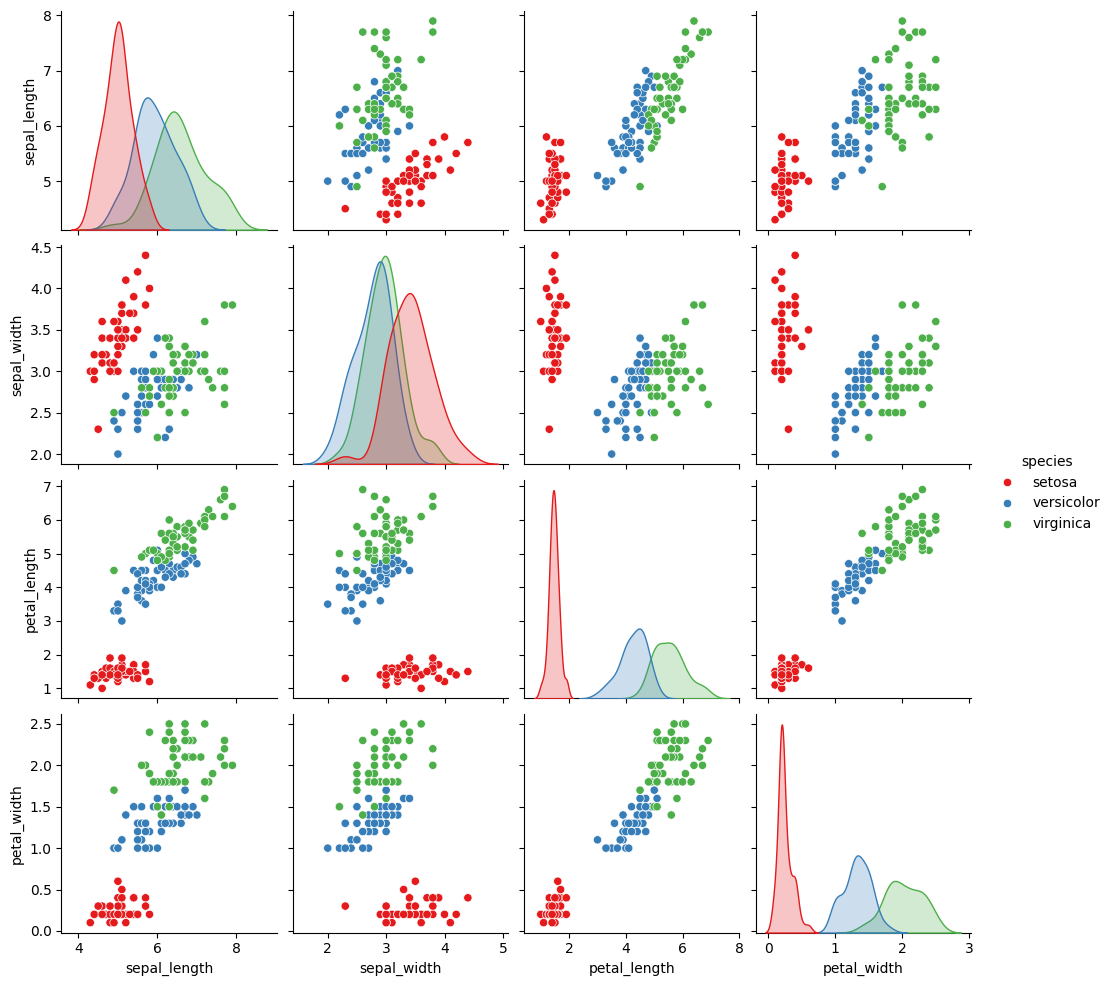

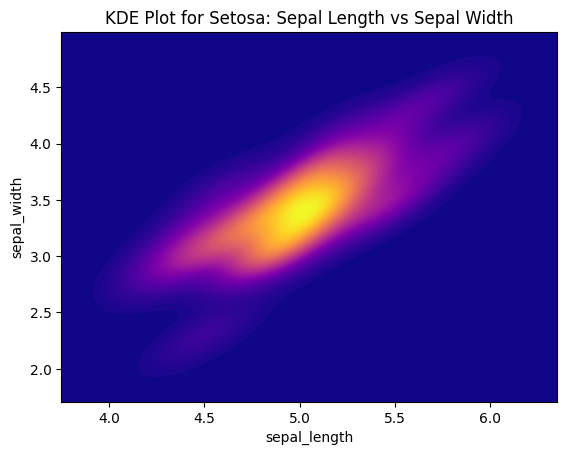

--- Initial SVC Model ---
Confusion Matrix:
[[13  0  0]
 [ 0 19  1]
 [ 0  0 12]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.95      0.97        20
   virginica       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END ...................................C=0.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Set up visualization
%matplotlib inline

# ------------------------------------------------------------
# 1. Get the Data
# ------------------------------------------------------------
iris = sns.load_dataset('iris')

# ------------------------------------------------------------
# 2. Exploratory Data Analysis (EDA)
# ------------------------------------------------------------
# Import libraries (already done above)

# Create a pairplot of the data set
sns.pairplot(iris, hue='species', palette='Set1')
plt.show()

# Create a kde plot of sepal_length versus sepal_width for setosa species
setosa = iris[iris['species'] == 'setosa']
sns.kdeplot(x=setosa['sepal_length'], y=setosa['sepal_width'], cmap='plasma', fill=True, thresh=0, levels=100)
plt.title('KDE Plot for Setosa: Sepal Length vs Sepal Width')
plt.show()

# ------------------------------------------------------------
# 3. Train Test Split
# ------------------------------------------------------------
X = iris.drop('species', axis=1)
y = iris['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# ------------------------------------------------------------
# 4. Train a Model (SVC)
# ------------------------------------------------------------
model = SVC()
model.fit(X_train, y_train)

# ------------------------------------------------------------
# 5. Model Evaluation
# ------------------------------------------------------------
predictions = model.predict(X_test)

print("--- Initial SVC Model ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# ------------------------------------------------------------
# 6. Gridsearch Practice
# ------------------------------------------------------------
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001]}

grid = GridSearchCV(SVC(), param_grid, verbose=2)
grid.fit(X_train, y_train)

# ------------------------------------------------------------
# 7. Evaluate GridSearch Model
# ------------------------------------------------------------
grid_predictions = grid.predict(X_test)

print("\n--- GridSearch SVC Model ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, grid_predictions))
print("\nClassification Report:")
print(classification_report(y_test, grid_predictions))

print("\nBest Parameters found by GridSearchCV:")
print(grid.best_params_)